# Audio feature analysis notebook (SIA short-form video popularity)

Ce notebook :
1. Charge `X_train.csv`, `y_train.csv`, `audio_features.csv`
2. Merge proprement sur l'ID
3. Analyse : corrélations, plots, importances LightGBM
4. Compare une baseline (sans audio) vs modèle avec audio via CV

> **À adapter** : le chemin `ROOT` si besoin.


In [17]:
# --- Imports ---
import os
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Optional: if you want nicer plots (not required)
try:
    import seaborn as sns
    _HAS_SEABORN = True
except Exception:
    _HAS_SEABORN = False

print("seaborn:", _HAS_SEABORN)


seaborn: True


In [18]:
import pandas as pd

ROOT = "/home/mohamed/SDD/hackathon/sia-predicting-short-form-video-popularity"

X_train = pd.read_csv(f"{ROOT}/X_train.csv", sep=";")
y_train = pd.read_csv(f"{ROOT}/y_train.csv", sep=";")
audio = pd.read_csv(f"{ROOT}/audio_features_scored.csv")
X_test  = pd.read_csv(f"{ROOT}/X_test.csv",  sep=";")
# Harmoniser les noms
y_train = y_train.rename(columns={"ID": "id"})
audio = audio.rename(columns={"ID": "id"})

# ✅ garder seulement les audios qui sont dans le train
train_ids = set(y_train["id"].astype(str))
test_ids  = set(X_test["id"].astype(str))
audio_train = audio[audio["id"].astype(str).isin(train_ids)].copy()
audio_test  = audio[audio["id"].astype(str).isin(test_ids)].copy()
print("audio total:", audio.shape)
print("audio train:", audio_train.shape)
print("audio test:", audio_test.shape)


audio total: (1686, 87)
audio train: (1348, 87)
audio test: (338, 87)


In [19]:
df_train = (
    X_train.merge(y_train, on="id", how="inner")
           .merge(audio_train, on="id", how="left")
)

print("df_train:", df_train.shape)
df_train.head()


df_train: (1348, 104)


,id,album,artist,artists,aspect_ratio,channel,description,video_duration,format,release_year,...,audio_energy_score,audio_brightness_score,audio_activity_score,tempo_x_onset,rms_x_tempo,centroid_x_bandwidth,mfcc_means_avg,mfcc_means_std,mfcc_stds_avg,audio_pop_audio_score
0,7602656035161050390,NaN,Urhov Bogdan,['Urhov Bogdan'],0.56,Davos Klosters,you dream you 🥹 #davosklosters #skiing #mounta...,13,1080x1920,2026,...,-0.418720,-0.694667,-1.161670,290.868339,10.425343,1.690448e+06,-2.441581,61.440521,13.362406,-0.696795
1,7590718903144287510,NaN,LykTraffx,['LykTraffx'],0.56,Davos Klosters,already missing this again 🥹 #spenglercup #dav...,12,1080x1920,2026,...,-0.243433,-1.421367,-0.975820,559.495211,1.276419,8.683464e+05,-34.759502,154.118693,24.474458,-0.698736
2,7571821778746592534,NaN,ALTÉGO,['ALTÉGO'],0.56,Davos Klosters,how??!!!🥹🥹 #davosklosters #skiing #ski #season...,13,1080x1920,2025,...,-0.813919,1.135333,-0.225904,293.176689,5.091624,4.182888e+06,-21.187374,52.375263,20.891341,-0.247664
3,7569927329154190614,NaN,Raye,['Raye'],0.56,Davos Klosters,We're back on snow!🥹🎿 #davosklosters #seasonop...,7,1080x1920,2025,...,-0.987357,1.259068,-0.411161,167.688380,2.455770,4.358288e+06,-13.918250,65.913807,13.439392,-0.365214
4,7566270741134462230,NaN,músicas e traduções,['músicas e traduções'],0.56,Davos Klosters,"Somebody send help, pls. 🥶 #davos #firstsnow #...",8,1080x1920,2025,...,-0.577606,0.526868,0.156950,421.599972,8.860062,3.273154e+06,1.445603,34.885610,11.785422,-0.136345


In [20]:
df_train = (
    X_train.merge(y_train, on="id", how="inner")
           .merge(audio_train, on="id", how="left")
)

print("df_train:", df_train.shape)
df_train.head()
X_test  = pd.read_csv(f"{ROOT}/X_test.csv",  sep=";")
df_test = (
    X_test.merge(audio_test, on="id", how="left")
)

df_train: (1348, 104)


In [21]:
import re
import numpy as np
import pandas as pd

_EMOJI_RE = re.compile(r"[\U00010000-\U0010ffff]", flags=re.UNICODE)

class FEProcessor:
    """
    Feature engineering train/test sans leakage.
    - calcule des features texte (description)
    - parse format WxH
    - frequency encoding sur colonnes catégorielles (basé sur le train)
    """
    def __init__(self,
                 cat_cols=("uploader", "artist", "channel", "album", "track"),
                 drop_cols=("artists", "format", "description", "filepath", "download_timing", "vid", "uid", "uploader_short")):
        self.cat_cols = list(cat_cols)
        self.drop_cols = list(drop_cols)
        self.freq_maps_ = {}  # col -> dict(value->freq)
        self.fitted_ = False

    @staticmethod
    def _safe_str(s):
        return s.fillna("").astype(str)

    def _add_text_feats(self, df: pd.DataFrame) -> pd.DataFrame:
        desc = self._safe_str(df.get("description", pd.Series([""] * len(df), index=df.index)))

        df["desc_len"] = desc.str.len()
        df["num_words"] = desc.str.split().str.len()
        df["num_hashtags"] = desc.str.count("#")
        df["num_mentions"] = desc.str.count("@")
        df["num_emojis"] = desc.apply(lambda x: len(_EMOJI_RE.findall(x)))
        df["hashtag_ratio"] = df["num_hashtags"] / (df["num_words"] + 1)

        return df

    def _add_format_feats(self, df: pd.DataFrame) -> pd.DataFrame:
        # format comme "1080x1920"
        if "format" in df.columns:
            wh = df["format"].astype(str).str.lower().str.split("x", expand=True)
            if wh.shape[1] >= 2:
                df["width"] = pd.to_numeric(wh[0], errors="coerce")
                df["height"] = pd.to_numeric(wh[1], errors="coerce")
                df["resolution"] = df["width"] * df["height"]
                df["is_vertical"] = (df["height"] > df["width"]).astype("Int64")
        return df

    def _add_time_feats(self, df: pd.DataFrame) -> pd.DataFrame:
        # download_timing -> hour/dayofweek (si dispo)
        if "download_timing" in df.columns:
            dt = pd.to_datetime(df["download_timing"], errors="coerce")
            df["download_hour"] = dt.dt.hour
            df["download_dow"] = dt.dt.dayofweek
        return df

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # base cleaning
        for c in ["album", "artist", "channel", "track", "uploader"]:
            if c in df.columns:
                df[c] = df[c].fillna("unknown").astype(str)

        df = self._add_text_feats(df)
        df = self._add_format_feats(df)
        df = self._add_time_feats(df)

        # frequency encoding basé TRAIN
        for col in self.cat_cols:
            if col in df.columns:
                freq = df[col].value_counts(dropna=False)
                self.freq_maps_[col] = freq.to_dict()
                df[col + "_freq"] = df[col].map(self.freq_maps_[col]).fillna(0).astype(float)

        # drop cols brutes
        df = df.drop(columns=self.drop_cols, errors="ignore")

        self.fitted_ = True
        return df

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self.fitted_:
            raise RuntimeError("FEProcessor non fit. Appelle fit_transform(train) d'abord.")

        df = df.copy()

        for c in ["album", "artist", "channel", "track", "uploader"]:
            if c in df.columns:
                df[c] = df[c].fillna("unknown").astype(str)

        df = self._add_text_feats(df)
        df = self._add_format_feats(df)
        df = self._add_time_feats(df)

        # appliquer les freq maps apprises sur train
        for col, fmap in self.freq_maps_.items():
            if col in df.columns:
                df[col + "_freq"] = df[col].map(fmap).fillna(0).astype(float)

        df = df.drop(columns=self.drop_cols, errors="ignore")
        return df

In [22]:
fe = FEProcessor()

Xtr_fe = fe.fit_transform(df_train)   # df_train = X_train + y_train + audio_train
Xte_fe = fe.transform(df_test)        # df_test  = X_test + audio_test

In [23]:
target_col = "popularity"

Xtr = Xtr_fe.select_dtypes(include="number").drop(columns=[target_col, "id", "ID"], errors="ignore")
ytr = df_train[target_col].astype(float)

Xte = Xte_fe.select_dtypes(include="number").drop(columns=["id", "ID"], errors="ignore")

# align colonnes
Xtr, Xte = Xtr.align(Xte, join="left", axis=1, fill_value=np.nan)

## Corrélations avec `popularity`

- Pearson sur les colonnes numériques
- On affiche le top 25 en valeur absolue


In [24]:
target_col = "popularity"
assert target_col in df_train.columns, "Colonne cible introuvable: popularity"

num_df = df_train.select_dtypes(include="number").copy()

# Optionnel : retirer les IDs s'ils sont numériques (parfois id peut être int)
for col in ["id", "ID"]:
    if col in num_df.columns:
        num_df = num_df.drop(columns=[col])

corr = num_df.corr(numeric_only=True)[target_col].dropna()
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

print("Top  corrélations (abs):")
display(corr_sorted)


Top  corrélations (abs):


popularity       1.000000
z_rms_mean      -0.124709
rms_mean        -0.124156
z_rms_std       -0.100760
rms_std         -0.100651
                   ...   
mfcc_11_mean    -0.002416
z_mfcc_6_mean    0.002302
mfcc_6_mean      0.001909
z_mfcc_1_std     0.001430
mfcc_1_std       0.001430
Name: popularity, Length: 90, dtype: float64

## Heatmap corrélations (optionnel)

Ça peut être lourd si tu as beaucoup de colonnes, donc on limite aux **50 features** les plus corrélées à `popularity`.


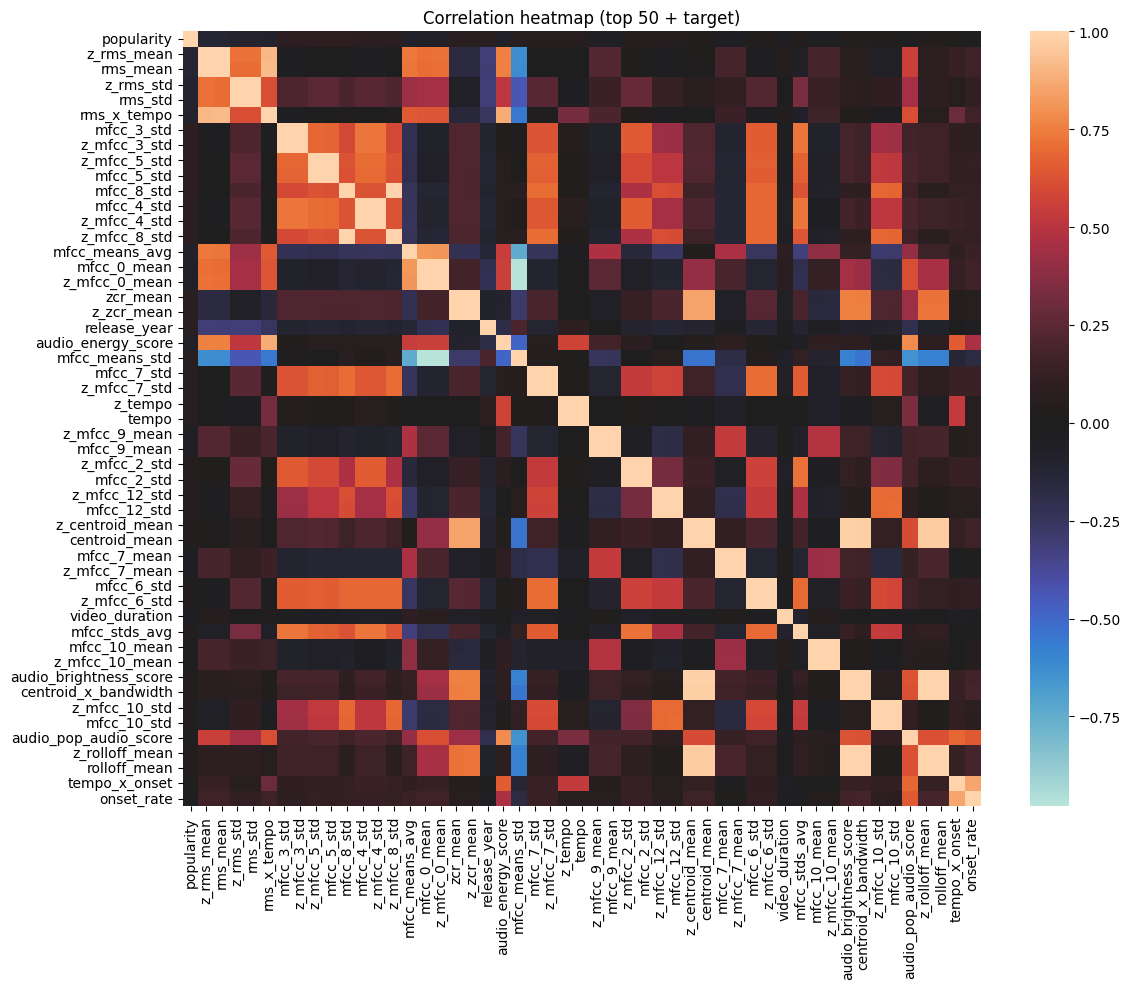

In [25]:
top_k = 50

# top corrélations, en retirant explicitement la cible
top_feats = corr_sorted.drop(index=[target_col], errors="ignore").head(top_k).index.tolist()

# colonnes finales : cible + top features (sans doublons)
cols = [target_col] + top_feats

# sécurité: enlever doublons si jamais
cols = list(dict.fromkeys(cols))
num_df = num_df.drop(columns=["id", "ID"], errors="ignore")
corr_small = num_df[cols].corr()

plt.figure(figsize=(12, 10))
if _HAS_SEABORN:
    sns.heatmap(corr_small, center=0)
else:
    plt.imshow(corr_small, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
plt.title(f"Correlation heatmap (top {top_k} + target)")
plt.tight_layout()
plt.show()

## Plots ciblés feature → popularity

On trace automatiquement quelques features audio typiques si elles existent.


Available candidates: ['tempo', 'onset_rate', 'rms_mean', 'rms_std', 'centroid_mean', 'rolloff_mean', 'zcr_mean', 'mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean']


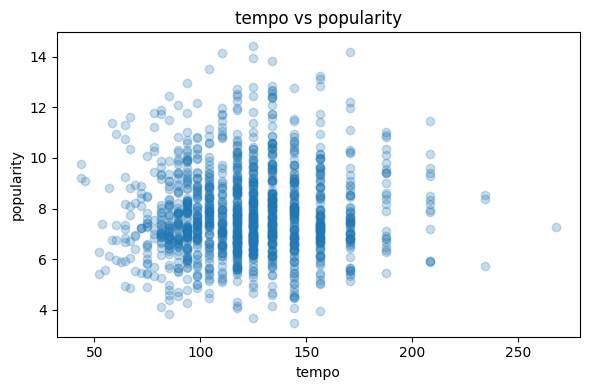

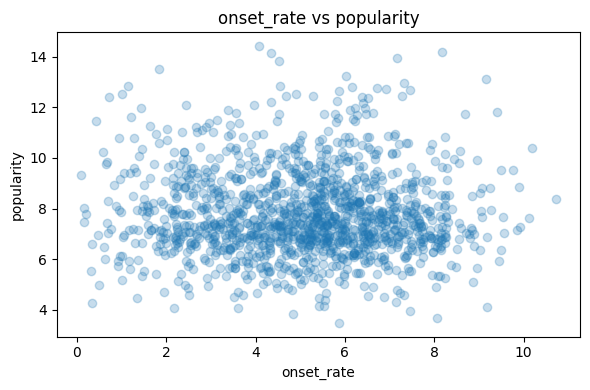

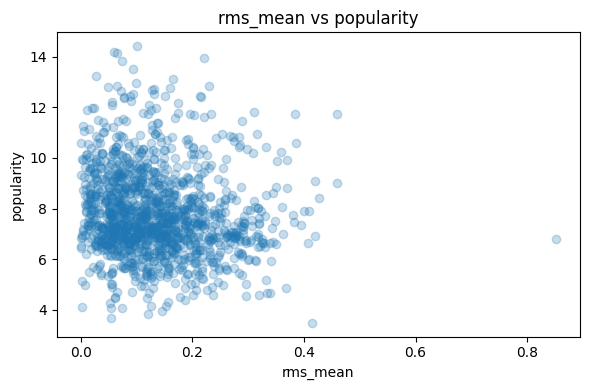

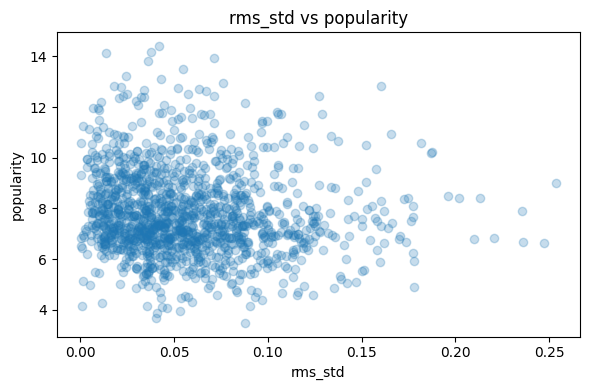

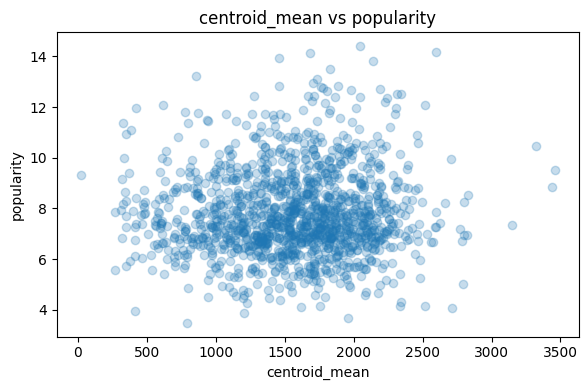

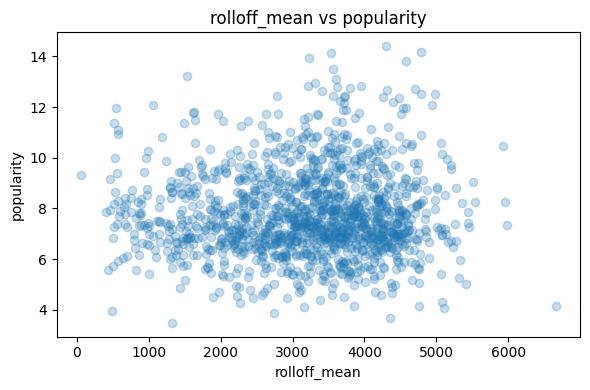

In [26]:
candidate_feats = [
    "tempo", "onset_rate", "rms_mean", "rms_std",
    "centroid_mean", "rolloff_mean", "zcr_mean",
    "mfcc_0_mean", "mfcc_1_mean", "mfcc_2_mean"
]

available = [c for c in candidate_feats if c in df_train.columns]
print("Available candidates:", available)

def scatter_plot(xcol):
    x = df_train[xcol]
    yv = df_train[target_col]
    mask = x.notna() & yv.notna()
    plt.figure(figsize=(6,4))
    plt.scatter(x[mask], yv[mask], alpha=0.25)
    plt.xlabel(xcol)
    plt.ylabel(target_col)
    plt.title(f"{xcol} vs {target_col}")
    plt.tight_layout()
    plt.show()

for c in available[:6]:
    scatter_plot(c)


## Popularity par quartiles (binning)

Ça met mieux en évidence des relations non-linéaires.


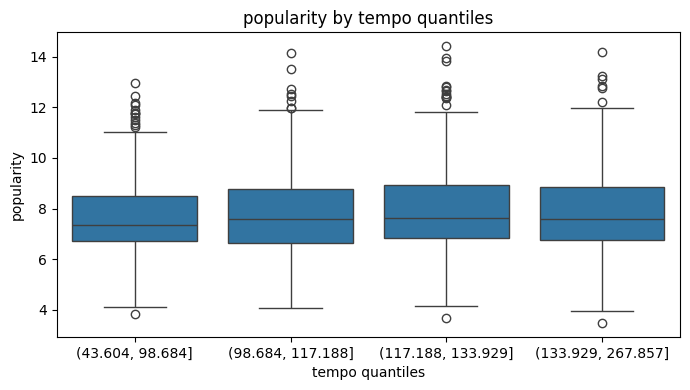

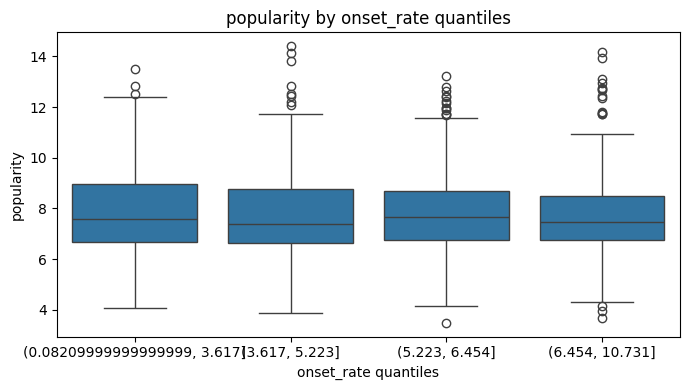

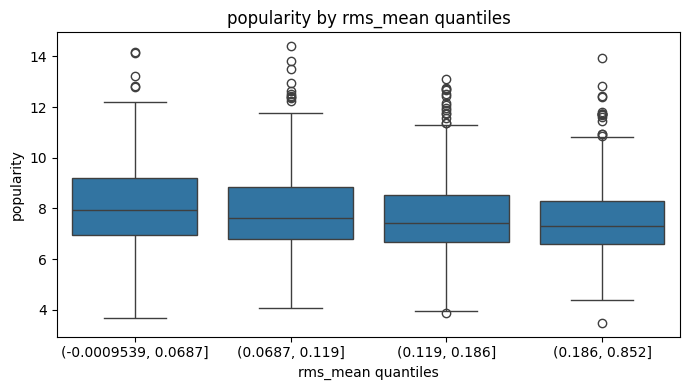

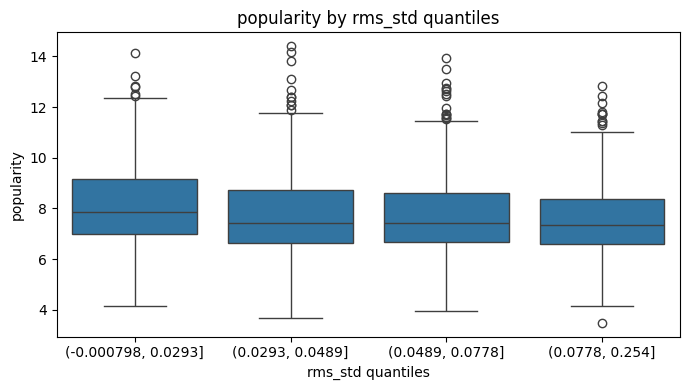

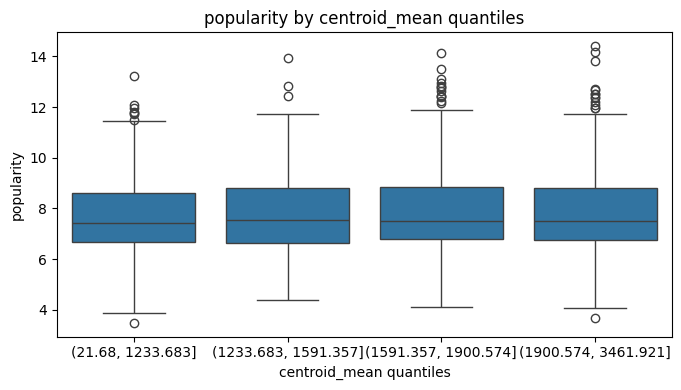

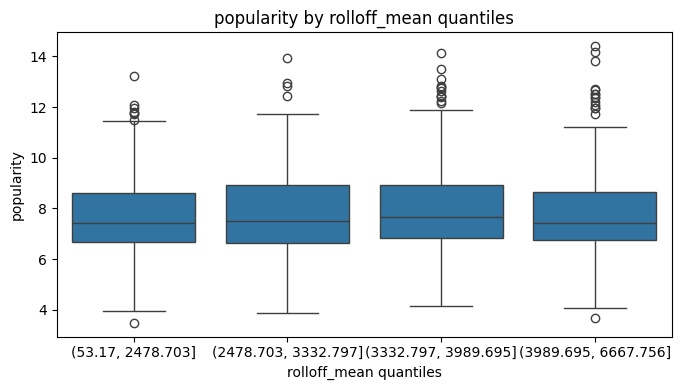

In [27]:
def boxplot_by_quantiles(xcol, q=4):
    tmp = df_train[[xcol, target_col]].dropna()
    if tmp.empty:
        print("No data for", xcol)
        return
    # duplicates='drop' évite les erreurs si beaucoup de valeurs identiques
    tmp["bin"] = pd.qcut(tmp[xcol], q, duplicates="drop")
    plt.figure(figsize=(7,4))
    if _HAS_SEABORN:
        sns.boxplot(x="bin", y=target_col, data=tmp)
    else:
        # fallback matplotlib: simple
        groups = [g[target_col].values for _, g in tmp.groupby("bin")]
        plt.boxplot(groups)
        plt.xticks(range(1, len(groups)+1), [str(k) for k in tmp["bin"].cat.categories], rotation=45, ha="right")
        plt.ylabel(target_col)
    plt.xlabel(f"{xcol} quantiles")
    plt.title(f"{target_col} by {xcol} quantiles")
    plt.tight_layout()
    plt.show()

for c in available[:6]:
    boxplot_by_quantiles(c, q=4)


## Importance des features via LightGBM

On entraîne un `LGBMRegressor` et on affiche le top 30 des importances.


In [28]:
# Install if missing (run once)
!python3 -m pip install -U lightgbm scikit-learn


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001774 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21998
[LightGBM] [Info] Number of data points in the train set: 1078, number of used features: 105
[LightGBM] [Info] Start training from score 7.837476
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22069
[LightGBM] [Info] Number of data points in the train set: 1078, number of used features: 105
[LightGBM] [Info] Start training from score 7.826250
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21988
[LightGBM] [Info] Number of data points in the train set: 1078, number of used features: 105
[LightGBM] [Info] Start 

zcr_mean                 475.6
tempo_x_onset            437.8
hashtag_ratio            387.4
desc_len                 364.4
audio_pop_audio_score    320.0
mfcc_3_mean              309.0
mfcc_8_mean              299.8
audio_activity_score     298.0
mfcc_4_std               294.2
mfcc_12_mean             291.8
mfcc_4_mean              289.4
mfcc_11_std              288.4
mfcc_0_std               284.8
mfcc_2_mean              280.2
mfcc_10_mean             278.4
mfcc_12_std              274.4
num_hashtags             271.2
mfcc_1_std               269.2
mfcc_6_mean              268.0
mfcc_3_std               267.8
audio_energy_score       265.8
mfcc_10_std              264.4
mfcc_11_mean             263.4
bandwidth_std            261.6
mfcc_9_mean              258.6
mfcc_7_mean              257.6
mfcc_2_std               251.4
mfcc_5_std               250.0
mfcc_7_std               242.6
mfcc_stds_avg            240.0
mfcc_8_std               240.0
zcr_std                  238.2
rms_std 

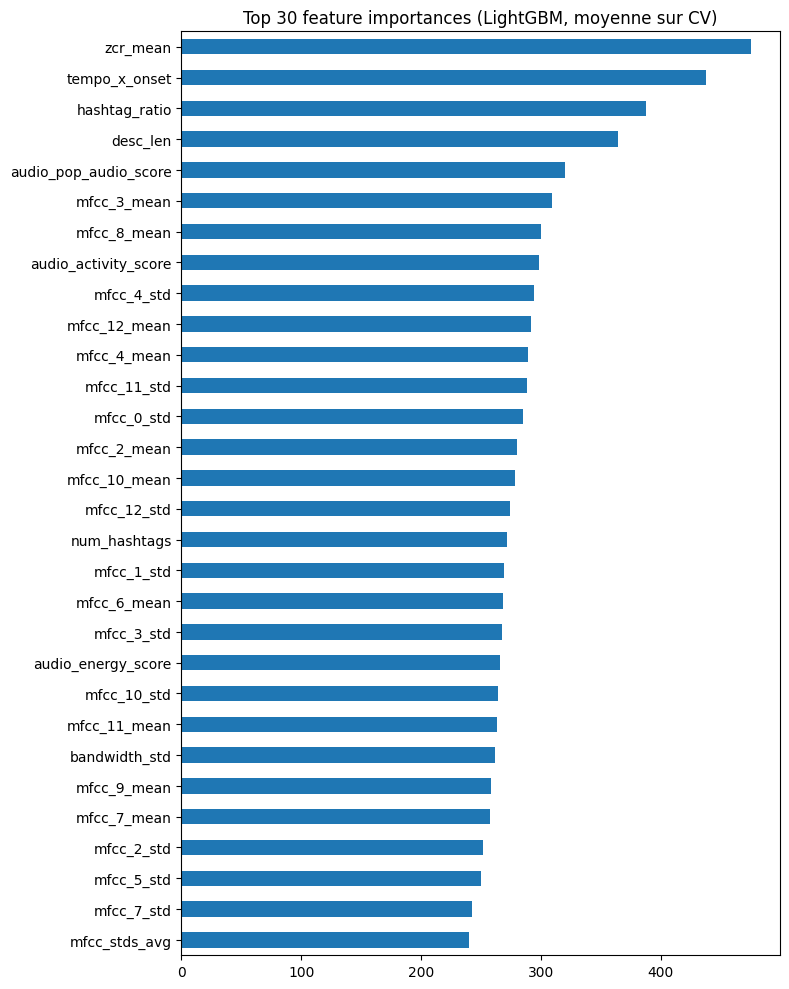

In [29]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor

# X_raw contient TOUT ce dont FEProcessor a besoin (cat/text/etc)
X_raw = df_train.drop(columns=[target_col], errors="ignore").copy()
y = df_train[target_col].astype(float)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
importances = []
feature_names_ref = None

for fold, (train_idx, val_idx) in enumerate(kf.split(X_raw), 1):
    X_tr_raw, X_va_raw = X_raw.iloc[train_idx].copy(), X_raw.iloc[val_idx].copy()
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    # ✅ FE sans fuite: fit sur train fold, apply sur val fold
    fe = FEProcessor()
    X_tr_fe = fe.fit_transform(X_tr_raw)
    X_va_fe = fe.transform(X_va_raw)

    # ne garder que numériques + virer id/ID si présents
    X_tr = X_tr_fe.select_dtypes(include="number").drop(columns=["id", "ID"], errors="ignore")
    X_va = X_va_fe.select_dtypes(include="number").drop(columns=["id", "ID"], errors="ignore")

    # ✅ aligner colonnes train/val (important si certaines features manquent)
    X_tr, X_va = X_tr.align(X_va, join="left", axis=1, fill_value=np.nan)

    # garder une référence des noms de features
    if feature_names_ref is None:
        feature_names_ref = X_tr.columns

    model = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
    model.fit(X_tr, y_tr)

    pred = model.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred))
    rmse_scores.append(rmse)

    importances.append(pd.Series(model.feature_importances_, index=X_tr.columns, name=f"fold_{fold}"))

rmse_scores = np.array(rmse_scores)

print("RMSE par fold:", rmse_scores)
print("RMSE moyen:", rmse_scores.mean())
print("RMSE std:", rmse_scores.std())

# Moyenne importances
imp_df = pd.concat(importances, axis=1).fillna(0)
imp_mean = imp_df.mean(axis=1).sort_values(ascending=False)

print("\nTop 55 importances (moyenne CV):")
display(imp_mean.head(55))

plt.figure(figsize=(8, 10))
imp_mean.head(30).sort_values().plot(kind="barh")
plt.title("Top 30 feature importances (LightGBM, moyenne sur CV)")
plt.tight_layout()
plt.show()

In [30]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model.fit(Xtr, ytr)

pred_test = model.predict(Xte)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002797 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22106
[LightGBM] [Info] Number of data points in the train set: 1348, number of used features: 105
[LightGBM] [Info] Start training from score 7.804249


In [31]:
submission = pd.DataFrame({
    "ID": df_test["id"].astype(str),
    "popularity": pred_test
})

sub_path = f"{ROOT}/submission.csv"
submission.to_csv(sub_path, index=False)
sub_path, submission.head()

('/home/mohamed/SDD/hackathon/sia-predicting-short-form-video-popularity/submission.csv',
                     ID  popularity
 0  7568823330518748438    8.859827
 1  7546523294489414934    8.610544
 2  7504292781637127446    7.194291
 3  7462655968522931478    9.560335
 4  7442737337525669142    8.241334)

## Prochaines étapes (recommandées)

- Ajouter le texte `description` (TF-IDF ou embeddings)
- Encodage des catégorielles (target/frequency encoding)
- Ajouter embeddings audio pré-entraînés (YAMNet/OpenL3) si tu veux pousser
